In [34]:
BODY_LENGTH = 71  # Y
BODY_WIDTH = 71  # X
KNEE_SHIFT_X = 27.43
KNEE_SHIFT_Y = 20
ANKLE_SHIFT_X = 55
PYATKA_SHIFT_Y = 18
PYATKA_SHIFT_Z = 80
import math

def test_solver(urdf_link_cls, ol_cls, ch_cls, initial_angles=(90, 90, 90)):
    leg1 = ch_cls(
        name="leg1",
        links=[
            ol_cls(),
            urdf_link_cls(
                name="hip",
                bounds=(math.radians(0), math.radians(180)),
                origin_translation=[BODY_WIDTH / 2, -BODY_LENGTH / 2, 0],
                origin_orientation=[0, 0, math.radians(-90)],
                rotation=[0, 0, 1],
            ),
            urdf_link_cls(
                name="knee",
                bounds=(math.radians(0), math.radians(180)),
                origin_translation=[KNEE_SHIFT_X, -KNEE_SHIFT_Y, 0],
                origin_orientation=[0, math.radians(180), 0],
                rotation=[0, -1, 0],
            ),
            urdf_link_cls(
                name="ankle",
                bounds=(math.radians(0), math.radians(180)),
                origin_translation=[0, 0, ANKLE_SHIFT_X],
                origin_orientation=[0, math.radians(-90), 0],
                rotation=[0, 1, 0],
            ),
            urdf_link_cls(
                name="pyatka",
                origin_translation=[PYATKA_SHIFT_Z, PYATKA_SHIFT_Y, 0],
                origin_orientation=[0, 0, 0],
                rotation=[1, 0, 0],
            ),
        ],
    )
    fk = leg1.forward_kinematics([0, *[math.radians(angle) for angle in initial_angles], 0])
    fk_x = fk[0][3]
    fk_y = fk[1][3]
    fk_z = fk[2][3]

    #print(f"FK: {fk_x=}, {fk_y=}, {fk_z=}")

    ik = leg1.inverse_kinematics([fk_x, fk_y, fk_z], optimizer="scalar")
    ik_degrees = [math.degrees(angle) for angle in ik[1:-1]]
    #print(f"IK: {ik_degrees=}")

    error = sum([(angle - ik_angle) ** 2 for angle, ik_angle in zip(initial_angles, ik_degrees)])
    #print(f"Error: {error=:0.5f}")
    return error


In [35]:
# Test shrinked solver for more angles
import concurrent.futures
from itertools import islice
from ikpy.chain import Chain as OriginalChain
from ikpy.link import OriginLink as OriginalOriginLink
from ikpy.link import URDFLink as OriginalURDFLink

from ikpy_min import Chain, OriginLink, URDFLink

TEST_ANGLES = [
]
step = 50
for a in range(0, 180, step):
    for b in range(0, 180, step):
        for c in range(0, 180, step):
            TEST_ANGLES.append((a, b, c))

stats = []

# Define the function to test a chunk of angles
def test_angle_chunk(chunk):
    chunk_stats = []
    for angles in chunk:
        original_error = test_solver(OriginalURDFLink, OriginalOriginLink, OriginalChain, angles)
        shrinked_error = test_solver(URDFLink, OriginLink, Chain, angles)
        stat = {
            "original_error": original_error,
            "shrinked_error": shrinked_error,
            "angles": angles,
            "failed": False
        }
        chunk_stats.append(stat)
    return chunk_stats

# Function to create chunks of 100 angles
def chunks(data, size=100):
    it = iter(data)
    for i in range(0, len(data), size):
        yield list(islice(it, size))

# Parallelize the testing using chunks of 100 angles
# with concurrent.futures.ThreadPoolExecutor() as executor:
#     # Divide TEST_ANGLES into chunks of 100
#     angle_chunks = list(chunks(TEST_ANGLES, size=100))
#     # Map each chunk to a worker
#     results = list(executor.map(test_angle_chunk, angle_chunks))

results = [test_angle_chunk(TEST_ANGLES)]


# Collect results
for result_chunk in results:
    for result in result_chunk:
        stats.append(result)

Total cases tested: 64, failed: 18, which is 28.12% failure


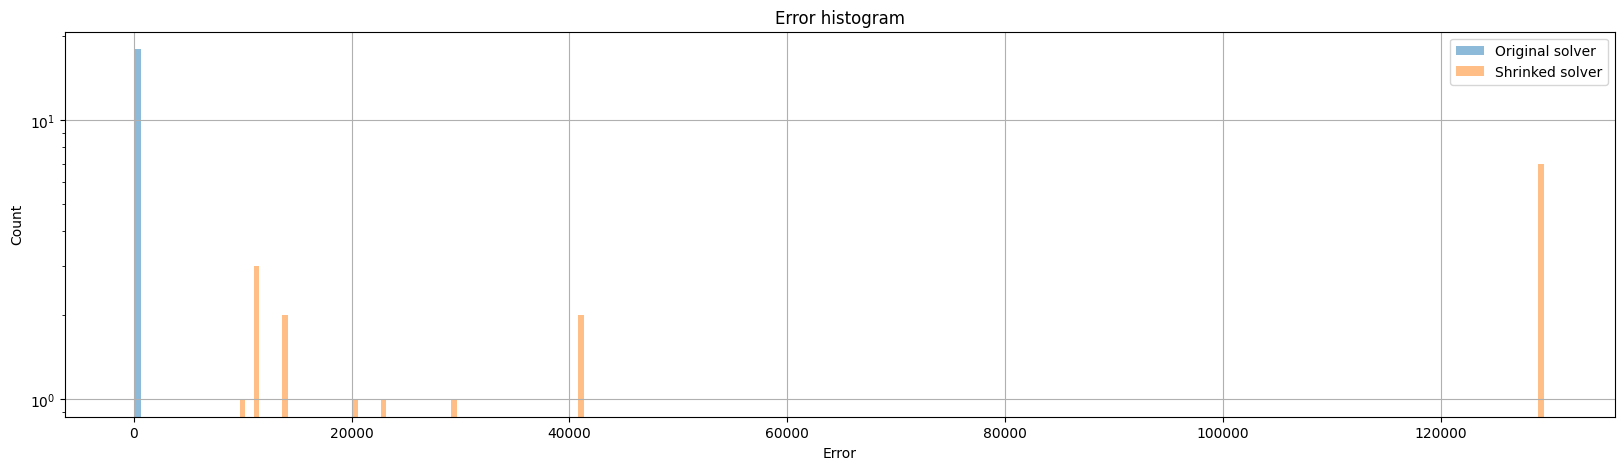

In [36]:
import matplotlib.pyplot as plt

def is_failure(stat):
    return stat["original_error"] < 10 and stat["shrinked_error"] - 1 > stat["original_error"]
failures = [stat for stat in stats if is_failure(stat)]

total_cases_tested = len(stats)
total_cases_failed = len(failures)
print(f"Total cases tested: {total_cases_tested}, failed: {total_cases_failed}, which is {total_cases_failed / total_cases_tested * 100:.2f}% failure")
original_error_histogam = [stat["original_error"] for stat in failures]
shrinked_error_histogam = [stat["shrinked_error"] for stat in failures]

plt.figure(figsize=(20, 5))
plt.hist([original_error_histogam, shrinked_error_histogam], bins=100, alpha=0.5, label=['Original solver', 'Shrinked solver'])
plt.grid(True)
plt.xlabel('Error')
plt.ylabel('Count')
plt.title('Error histogram')
plt.legend(loc='upper right')
plt.yscale("log")

plt.show()